In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Prepare data
## 1.1 Get your X and y in the right shape

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

# diabetes #dictionary of numpy arrays - bunch

print("Features: ", diabetes.feature_names)

Features:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
X = diabetes.data
print(X.shape) #(442 = number of samples, 10 = features)(m, n)
X

(442, 10)


array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [4]:
y = diabetes.target

print(y.shape) #small letter y represents vector
print("values",y[0:3])
print(y[0])

(442,)
values [151.  75. 141.]
151.0


In [6]:
m = X.shape[0] # # of samples
n = X.shape[1] # # of features
print(X[0])  #big letter X represents matrix

[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [7]:
assert m == y.shape[0]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
y_test.shape

(89,)

In [9]:
# Feature scale your data to reach faster convergence
print(X_train[0])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

[ 0.04170844 -0.04464164 -0.00836158 -0.02632753  0.02457414  0.01622244
  0.07072993 -0.03949338 -0.04835926 -0.03007245]


In [10]:
X_train[0]

array([ 0.89638272, -0.96382662, -0.16014574, -0.58496936,  0.49318418,
        0.30915729,  1.54759524, -0.8871132 , -1.05683682, -0.66528339])

In [11]:
intercept = np.ones((X_train.shape[0], 1)) # add 1 
X_train = np.concatenate((intercept, X_train), axis = 1)
intercept = np.ones((X_test.shape[0], 1))
X_test = np.concatenate((intercept, X_test), axis = 1)
X_test[0]

array([ 1.        , -2.19368661,  1.03753101, -0.9434397 , -0.58496936,
       -0.54291841, -0.551007  ,  0.67000308, -0.8871132 , -0.87220868,
       -1.18890665])

In [12]:
# 1.5. Feature Engineering (optional)

# It is sometimes useful to engineer new features (e.g., polynomial, kernels) so to create some non-linear relationships with your target. Here we gonna skip


from time import time

theta = np.zeros(X_train.shape[1])

lr = 0.001 #alpha

max_iter = 50

#three steps to gradient descent

start = time()

for i in range(max_iter):
    #1. prediction
    # X @ w
    print(f"step{i}")
    y_hat = X_train @ theta

    #2. calculate gradient
    # grad = X^T (h - y)
    grad = X_train.T @ (y_hat - y_train)

    #3. update the theta
    # w = w - lr * grad
    theta = theta - lr * grad
    print(theta)

time_taken = time() - start

print("Time taken: ", time_taken)
print("Theta: ", theta)

step0
[ 5.34470000e+01  5.02235839e+00 -3.07177213e-02  1.61669092e+01
  1.11569265e+01  5.46355838e+00  3.96897224e+00 -9.40102135e+00
  1.05533321e+01  1.54764607e+01  1.02487259e+01]
step1
[88.027209    1.52289569 -5.11889665 17.81421056 10.2058852  -0.67850818
 -3.35537329 -7.31063215  4.88526788 14.71679194  6.68498354]
step2
[110.40060422   1.78691817  -6.73491536  22.06654241  12.25360225
  -0.47854968  -3.82513317  -8.63330554   5.95693862  18.47014167
   7.55038128]
step3
[124.87619093   1.03042584  -8.46746207  23.60770693  12.3524671
  -1.68138825  -5.44326499  -8.30050401   4.89355426  19.5029954
   6.46550439]
step4
[134.24189553   0.92019929  -9.32072389  25.08650024  12.74101087
  -1.87594013  -5.83957215  -8.4335463    4.86207611  20.87415962
   6.04919255]
step5
[140.30150641   0.74123272  -9.93760145  25.90572283  12.78565038
  -2.20836372  -6.24195508  -8.32956021   4.57942161  21.65880973
   5.42486659]
step6
[144.22207465   0.69908291 -10.27003354  26.53281129  12.

In [13]:
## 2.2 Compute accuracy/loss

#for regression, mean squared error
#for classification, accuracy, recall, precision


def mse(yhat, y):
   return  ((yhat - y)**2).sum() / yhat.shape[0]


#training mse
yhat_train = X_train @ theta

mse_train = mse(yhat_train, y_train)

print("MSE train: ", mse_train)

#testing mse

yhat_test = X_test @ theta

mse_test = mse(yhat_test, y_test)

print("MSE test: ", mse_test)

MSE train:  2845.2163380590355
MSE test:  3070.189413362892


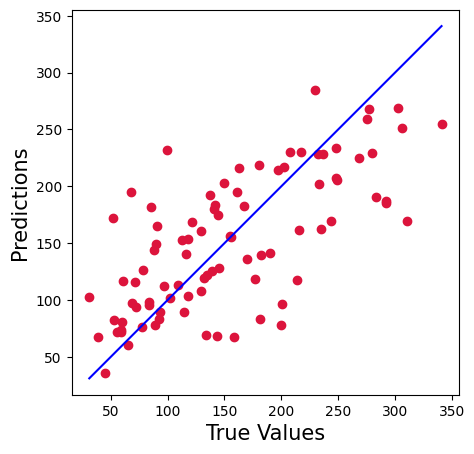

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_test, c='crimson')

p1 = max(max(yhat_test), max(y_test))
p2 = min(min(yhat_test), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

In [15]:
def cross_entropy_loss(y, h):
    loss = - np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    
    return loss
y      = np.array([1, 1, 1, 0, 0, 0])
bad_h  = np.array([0.01, 0.01, 0.01, 0.99, 0.99, 0.99])  #<---very bad prediction
good_h = np.array([0.99, 0.99, 0.99, 0.01, 0.01, 0.01])  #<---very good prediction


print("bad h should give high loss: ", cross_entropy_loss(y, bad_h))
print("good h should give low loss: ", cross_entropy_loss(y, good_h))

bad h should give high loss:  27.631021115928544
good h should give low loss:  0.060302015121008704


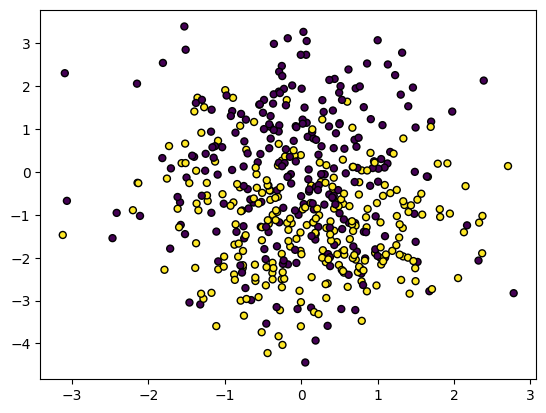

In [16]:
from sklearn import linear_model
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=500, n_features=10, n_redundant=2, n_informative=4,
                             n_clusters_per_class=2, random_state=14)
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y,
            s=25, edgecolor='k')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# feature scaling helps reaching convergence faster
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#add intercepts
intercept = np.ones((X_train.shape[0], 1))
X_train   = np.concatenate((intercept, X_train), axis=1)  # add intercept
intercept = np.ones((X_test.shape[0], 1))
X_test    = np.concatenate((intercept, X_test), axis=1)  

In [17]:
##### 2: Fit your algo
# here I use mini-batch as a demonstration
# you are free to use any variants of gradient descent
def mini_batch_GD(X, y, max_iter=1000):
    w = np.zeros(X.shape[1])
    l_rate = 0.01

    batch_size = int(0.1 * X.shape[0])
    for i in range(max_iter):
        ix = np.random.randint(0, X.shape[0]) #<----with replacement
        batch_X = X[ix:ix+batch_size]
        batch_y = y[ix:ix+batch_size]
        loss, grad = gradient(batch_X, batch_y, w)
        if i % 500 == 0:
            print(f"Loss at iteration {i}", loss)
        w = w - l_rate * grad
    return w, i

def gradient(X, y, w):
    m = X.shape[0]
    h = h_theta(X, w)
    error = h - y
    # putting negative sign for negative log likelihood
    loss = - np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    grad = np.dot(X.T, error)
    return loss, grad

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
        
def h_theta(X, w):
    return sigmoid(X @ w)

def output(pred):
    return np.round(pred)

w, i = mini_batch_GD(X_train, y_train, max_iter=5000)

Loss at iteration 0 24.26015131959808
Loss at iteration 500 11.765593513094485
Loss at iteration 1000 17.33617884805168
Loss at iteration 1500 19.367949363835603
Loss at iteration 2000 13.587769940345666
Loss at iteration 2500 18.718237832080238
Loss at iteration 3000 15.497426195073391
Loss at iteration 3500 11.721799887992386
Loss at iteration 4000 10.686240463592748
Loss at iteration 4500 14.066915763694263
